#### Name: 

# PHYS 230 Lab Assignment 17

### Wednesday, April 8, 2026: Chapter 10.1
- Random numbers

In [1]:
# import statements here
import matplotlib.pyplot as plt
import numpy as np
import random

## Part 1: Testing random number generators

#### Step 1: Write a function `LCM_random(a,c,m,N,x)` that generates a list of $N$ random numbers using the linear congruent method from a starting seed $x$. 

In [4]:
def rand(seed,N=1,a=166425,c=1013904223,m=4294967296): #I much prefer this order, as we are commonly using specific a/c/m and then our seed usually varies
    list = []
    x = seed
    for i in range(N+1):
        x = (a*x+c)%m
        list.append(x)
    return np.array(list,float)

def LCM_random(a=166425,c=1013904223,m=4294967296,N=1,x=1): #Correct order as wanted in the text above
    list = []
    for i in range(N+1):
        x = (a*x+c)%m
        list.append(x)
    return list #returns a list, not an array

#### Step 2: Call on your function from step 1 using the most accepted values of the constants $a,c$, and $m$, and whatever you want to use as the seed. Create an array $r$ of 1000 points. Repeat testing at least three different seeds total. 

In [ ]:
N = 1000 #length of arrays
r1 = rand(seed=3,N=N) #Random array, with a set seed and length
r1 = r1/np.max(r1)
r2 = rand(seed=81,N=N)
r2 = r2/np.max(r2)
r3 = rand(seed=243,N=N)
r3 = r3/np.max(r3)

#### Step 3: Make a plot (or separate plots may be best) of your arrays using Matplotlib Pyplot (simply feed in a single 1D array) to see how random the data truly is. In a markdown cell, explain any differences you notice when you use different seed values. 

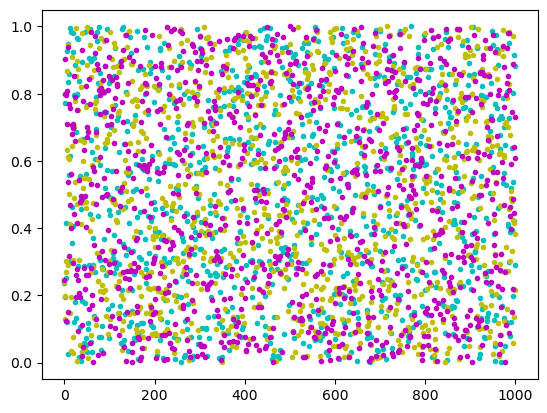

In [19]:
plt.plot(r1,"c.")
#plt.show()
plt.plot(r2,"y.")
#plt.show()
plt.plot(r3,"m.")
plt.show()


#### Step 4: Make a plot of successive random numbers for one of your arrays, where your plot points should be ($x,y$) = ($r_i$, $r_{i+1}$). What do you notice about this plot? Do the values truly seem random? 

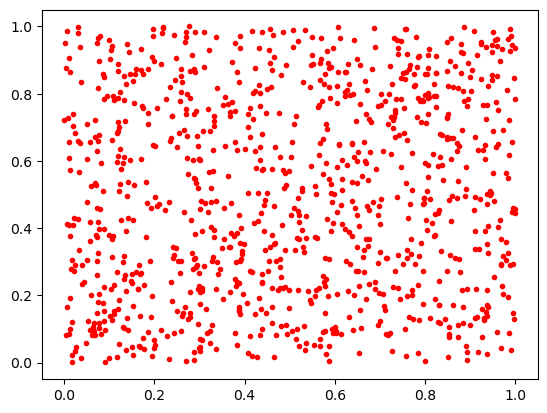

In [20]:
plt.plot(r1,r2,"r.")
plt.show()

#### Step 5: Now try an unwise choice of constant for the linear congruent method. Try using $(a,c,m,x) = (57,1,256,10)$ to generate 1000 random values. Make a 1D plot and also the plot (x,y) = ($r_i$, $r_{i+1}$). Explain what you notice about these plots compared to above. 

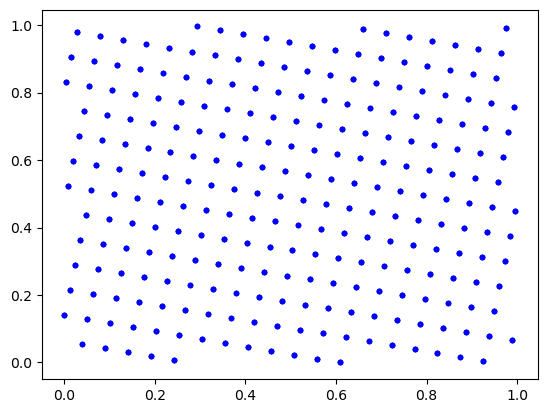

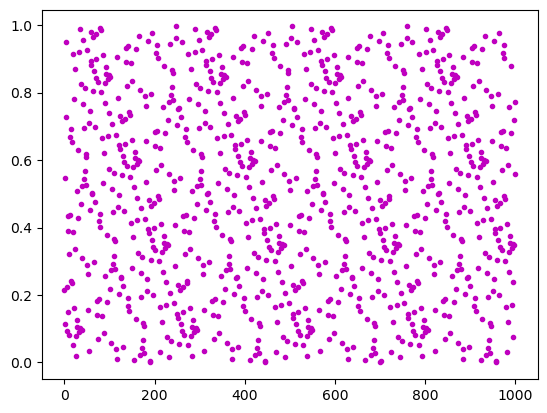

In [37]:
r1 = rand(seed=10,N=1000,a=77,c=1,m=256)/256
r2 = rand(seed=14,N=1000,a=77,c=1,m=256)/256

plt.plot(r1,r2,"b.")
plt.show()
plt.plot(r2,"m.")
plt.show()

Noticeably, this distribution is not very random is very clearly periodic. Specifically, given the output it is easy to guess a random number based on the previous random number. In the previous result I imagine we would require a much larger count of random values before we have periodic behavior.

#### Step 6: Use a built-in random number generator from the `random` package to create an array of 1000 points. Plot the results and compare as done in steps 3 and 4 above. (Don't forget to include a markdown with your comparison.) 

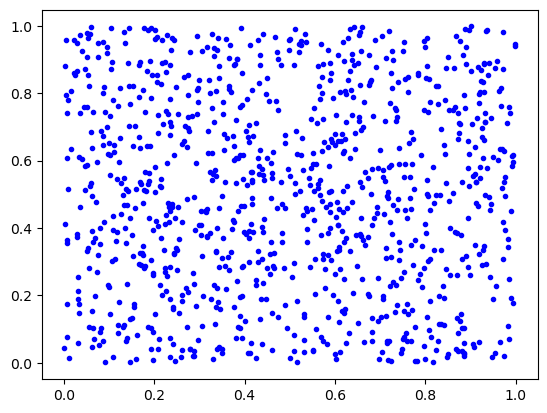

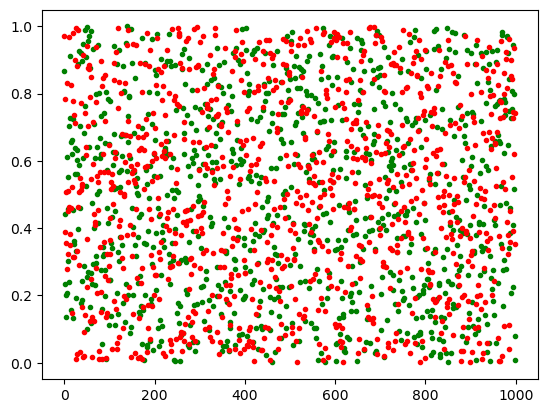

In [44]:
N = 1000
random_list_1 = np.array([random.random() for i in range(N)]) #creating a list of random numbers using list comprehension, then converting into an array
random_list_2 = np.array([random.random() for i in range(N)])

#Plotting as seen in steps 3 & 4
plt.plot(random_list_1,random_list_2,"b.")
plt.show()
plt.plot(random_list_1,"g.")
plt.plot(random_list_2,"r.")
plt.show()

It looks random like steps 3 & 4. I cannot particullarly tell the difference.

## Part 2: Luck & Roulette 
(background information taken from [Wikipedia](https://en.wikipedia.org/wiki/Roulette))

Roulette is a casino game named after the French word meaning little wheel. In the game, a player may choose to place a bet on a single number, various groupings of numbers, the color red or black, whether the number is odd or even, or if the numbers are high (19–36) or low (1–18).

To determine the winning number, a croupier spins a wheel in one direction, then spins a ball in the opposite direction around a tilted circular track running around the outer edge of the wheel. The ball eventually loses momentum, passes through an area of deflectors, and falls onto the wheel and into one of  thirty-eight colored and numbered pockets on the wheel.

As explained above, there are many betting options for Roulette, seen on the roulette table layout below. One of the most common bets is either red or black. 

In this part of the lab, we're going to use a random number generator to determine the odds of winning when a gambling soul chooses red. 


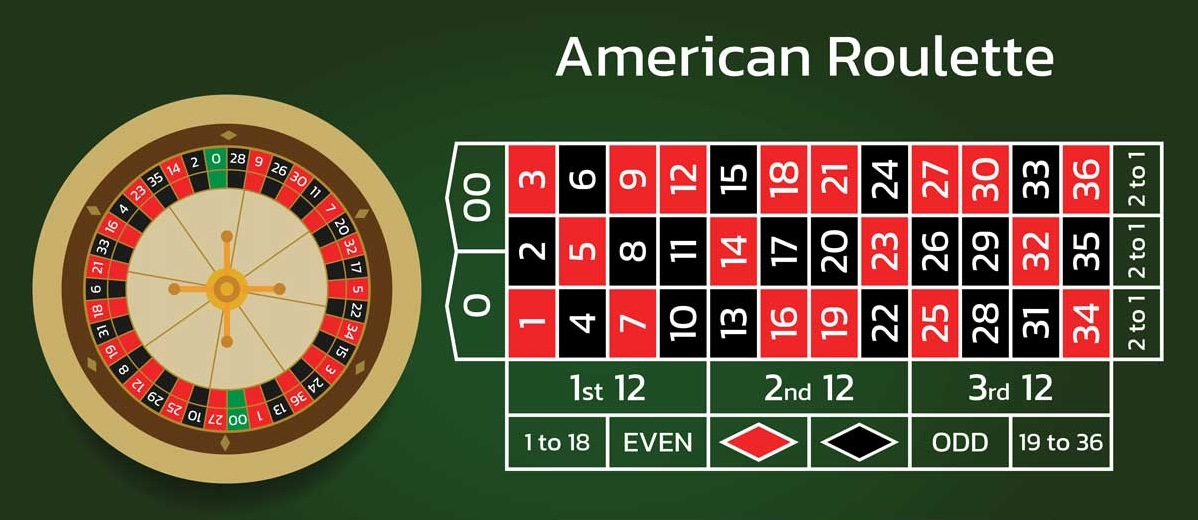

#### Step 1: Create two lists - `red` and `black` - which each contain all of the numbers that belong to those classifications. 

In [49]:
red     = [1,3,5,7,9, 12,14,16,18,19,21,23,25,27,30,32,36,34]
black   = [2,6,4,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35]
green   = [37,38]

#### Step 2: Develop a *function* to spin the roulette wheel $N$ times. 

In the code it should: 
- create three variables (red_count, black_count, green_count) initially set equal to 0 (Green count will be used to keep track of 0 & 00)
- select a random number between 1 and 38 (37 and 38 are being used to represent 0 and 00 for this game)
- check if that number is in red or black list (or neither) - this would be best done with if, elif, and else
- if the number is red, black, or neither, add one to the corresponding variable from step 2. 

In [50]:
def Spin_The_Wheel(N):
    #initializing our counts
    red_N,black_N,green_N = 0,0,0
    #For loop to iterate for how many times we want
    for i in range(N):
        #Integer random place where ball lands
        ball = random.randrange(1,39,1)
        if ball in red:
            red_N += 1
        if ball in black:
            black_N+=1
        if ball in green:
            green_N+=1
    return np.array([red_N,black_N,green_N])
            

#### Step 3: Call on your function to spin the roulette wheel 100, 1000, and 10,000 times. 

For each completion, determine what percentage of the spins were indeed red. 

In [55]:
for n in [100,1000,10000]:
    Percent_Red = 100*Spin_The_Wheel(n)[0]/n
    print("The wheel was spun", n, "times.")
    print("Percentage of Red Balls: ", round(Percent_Red,1), "%",sep="")
    print()


The wheel was spun 100 times.
Percentage of Red Balls: 40.0%

The wheel was spun 1000 times.
Percentage of Red Balls: 45.9%

The wheel was spun 10000 times.
Percentage of Red Balls: 47.5%



#### Step 4: Vegas pays 1:1 for a red or black winning number, which would suggest you have a 50% chance of getting it right. Is this correct or is Vegas always putting the odds in their favor? Explain briefly. 

There is a slight bias towards the house. This bias specifically comes about because of the '0' rolls, because this makes our equation go from:
$$\text{Chance of winning} = \frac{\text{Red}}{\text{Red}+\text{Black}} = 50\%$$
To
$$\text{Chance of winning} = \frac{\text{Red}}{\text{Red}+\text{Black} + \text{Green}}\approx 47\%$$

Interestingly, Las Vegas has started to add tripple '0's, making it even more in their favor. Specifically, the chance would then be $46\%$